# 📘 CIFAR-10 Image Classification Learning Project


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

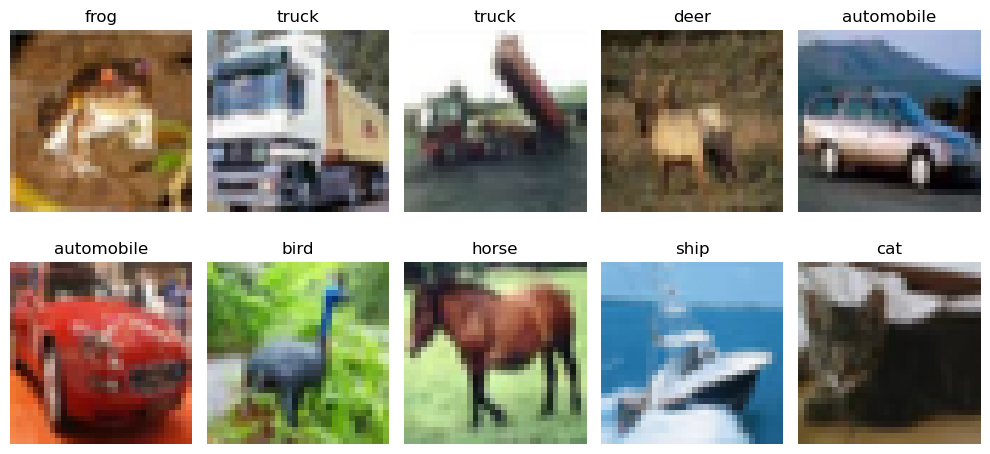

In [5]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing

In [7]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

# 🔹 Part 2: CNN Model

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

## 📈 Compare Learning Curves

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

In [ ]:
# Helper functions — called by Tasks 1, 3, and 4
# Defined here once so every task uses the exact same baseline architecture

def build_ann():
    """Returns a freshly compiled baseline ANN — same architecture as the original notebook."""
    m = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(3072,)),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


def build_cnn():
    """Returns a freshly compiled baseline CNN — same architecture as the original notebook."""
    m = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


print('build_ann() and build_cnn() are ready to use.')

---
## ✅ Task 1 — Increase ANN Layers and Observe Performance

In [ ]:

ann_baseline_cfg = build_ann()   # reference only — check param count
print(f'Baseline ANN param count : {ann_baseline_cfg.count_params():,}')

ann_deep = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),   # same as baseline
    layers.Dropout(0.3),                                          # same as baseline
    layers.Dense(384, activation='relu'),   # NEW — extra layer
    layers.Dropout(0.3),                    # NEW — matched dropout
    layers.Dense(256, activation='relu'),   # same as baseline
    layers.Dense(128, activation='relu'),   # NEW — extra layer
    layers.Dense(10, activation='softmax')  # same as baseline
])
ann_deep.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])
print(f'Deeper   ANN param count : {ann_deep.count_params():,}')

ann_deep_hist = ann_deep.fit(
    x_train_flat, y_train,
    epochs=10, validation_split=0.1, batch_size=64
)

_, ann_deep_acc = ann_deep.evaluate(x_test_flat, y_test, verbose=0)

print(f'\nBaseline ANN (2 hidden layers) : {ann_test_acc:.4f}')
print(f'Deeper   ANN (4 hidden layers) : {ann_deep_acc:.4f}')
print(f'Change                         : {(ann_deep_acc - ann_test_acc)*100:+.2f}%')

# ── Side-by-side: val_accuracy AND val_loss ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Task 1 — Baseline vs Deeper ANN', fontweight='bold')

axes[0].plot(ann_history.history['val_accuracy'],    label='Baseline ANN (2 layers)')
axes[0].plot(ann_deep_hist.history['val_accuracy'],  label='Deeper ANN (4 layers)')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ann_history.history['val_loss'],    label='Baseline ANN (2 layers)')
axes[1].plot(ann_deep_hist.history['val_loss'],  label='Deeper ANN (4 layers)')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## ✅ Task 2 — Change CNN Filters from 32 → 64 → 128


In [ ]:
# Task 2 — demonstrating the 32 → 64 → 128 filter progression

cnn_task2 = build_cnn()   # 32 → 64 → 128, same as the original

# Print how the spatial dimensions change at each stage
print('--- Spatial dimensions through each Conv block ---')
for layer in cnn_task2.layers:
    if hasattr(layer, 'output_shape'):
        print(f'  {layer.name:<30} output shape: {layer.output_shape}')

print('\nTraining CNN (32→64→128) for 10 epochs...')
cnn_t2_hist = cnn_task2.fit(
    x_train_norm, y_train,
    epochs=10, validation_split=0.1, batch_size=64
)

_, cnn_t2_acc = cnn_task2.evaluate(x_test_norm, y_test, verbose=0)

print(f'\nANN  test accuracy          : {ann_test_acc:.4f}')
print(f'CNN (32→64→128) test accuracy: {cnn_t2_acc:.4f}')
print(f'Improvement over ANN         : {(cnn_t2_acc - ann_test_acc)*100:+.2f}%')

# Side-by-side: val accuracy and val loss
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Task 2 — Why 32→64→128 Works: ANN vs CNN', fontweight='bold')

axes[0].plot(ann_history.history['val_accuracy'], 'o--', label='ANN (flat vector)')
axes[0].plot(cnn_t2_hist.history['val_accuracy'], 's-',  label='CNN (32→64→128)')
axes[0].set_title('Validation Accuracy'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ann_history.history['val_loss'], 'o--', label='ANN val loss')
axes[1].plot(cnn_t2_hist.history['val_loss'], 's-',  label='CNN val loss')
axes[1].set_title('Validation Loss'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## ✅ Task 3 — Increase Epochs to 20

In [ ]:
# Task 3 — 20-epoch training using the helper functions defined above

ann_20 = build_ann()
cnn_20 = build_cnn()

print('Training ANN for 20 epochs...')
ann_20_hist = ann_20.fit(
    x_train_flat, y_train,
    epochs=20, validation_split=0.1, batch_size=64
)

print('\nTraining CNN for 20 epochs...')
cnn_20_hist = cnn_20.fit(
    x_train_norm, y_train,
    epochs=20, validation_split=0.1, batch_size=64
)

_, ann_20_acc = ann_20.evaluate(x_test_flat,  y_test, verbose=0)
_, cnn_20_acc = cnn_20.evaluate(x_test_norm, y_test, verbose=0)

print(f'\nANN  — 10ep: {ann_test_acc:.4f}  |  20ep: {ann_20_acc:.4f}  |  delta: {(ann_20_acc - ann_test_acc)*100:+.2f}%')
print(f'CNN  — 10ep: {cnn_test_acc:.4f}  |  20ep: {cnn_20_acc:.4f}  |  delta: {(cnn_20_acc - cnn_test_acc)*100:+.2f}%')

# Four-panel plot: accuracy + loss for both models
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Task 3 — ANN vs CNN at 20 Epochs', fontweight='bold')
epochs_range = range(1, 21)

for row, (hist, name, col) in enumerate([
    (ann_20_hist, 'ANN', '#E07B39'),
    (cnn_20_hist, 'CNN', '#3A86FF')
]):
    # Accuracy subplot
    axes[row][0].plot(epochs_range, hist.history['accuracy'],
                      '--', color=col, alpha=0.5, label='Train Acc')
    axes[row][0].plot(epochs_range, hist.history['val_accuracy'],
                      '-',  color=col, linewidth=2, label='Val Acc')
    axes[row][0].set_title(f'{name} — Accuracy')
    axes[row][0].set_xlabel('Epoch'); axes[row][0].set_ylabel('Accuracy')
    axes[row][0].legend(); axes[row][0].grid(alpha=0.3); axes[row][0].set_ylim(0, 1)

    # Loss subplot
    axes[row][1].plot(epochs_range, hist.history['loss'],
                      '--', color=col, alpha=0.5, label='Train Loss')
    axes[row][1].plot(epochs_range, hist.history['val_loss'],
                      '-',  color=col, linewidth=2, label='Val Loss')
    axes[row][1].set_title(f'{name} — Loss')
    axes[row][1].set_xlabel('Epoch'); axes[row][1].set_ylabel('Loss')
    axes[row][1].legend(); axes[row][1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## ✅ Task 4 — Add EarlyStopping

In [ ]:
# Task 4 — EarlyStopping on the CNN
# Using build_cnn() so the architecture is identical to the baseline
from tensorflow.keras import callbacks

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

cnn_es = build_cnn()   # fresh weights, same architecture as original

# Setting epochs=50 — EarlyStopping will stop well before that if val_loss stagnates
cnn_es_hist = cnn_es.fit(
    x_train_norm, y_train,
    epochs=50,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

_, cnn_es_acc = cnn_es.evaluate(x_test_norm, y_test, verbose=0)

actual_epochs = len(cnn_es_hist.history['val_loss'])
best_ep       = int(np.argmin(cnn_es_hist.history['val_loss'])) + 1

print(f'\nStopped at epoch : {actual_epochs} / 50')
print(f'Best val_loss at : epoch {best_ep}')
print(f'CNN w/ EarlyStopping test accuracy : {cnn_es_acc:.4f}')
print(f'CNN baseline (10 epochs)           : {cnn_test_acc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Task 4 — CNN with EarlyStopping', fontweight='bold')

for ax, metric, ylabel in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
    ax.plot(cnn_es_hist.history[metric],          '--', alpha=0.5, label=f'Train {ylabel}')
    ax.plot(cnn_es_hist.history[f'val_{metric}'],  '-', linewidth=2, label=f'Val {ylabel}')
    ax.axvline(best_ep - 1, color='red', linestyle=':', label=f'Best epoch ({best_ep})')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} curve'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

---
## ✅ Task 5 — Add Data Augmentation Training

In [ ]:
# Task 5 — training the aug_cnn_model that was built (but not trained) in the original notebook
# aug_cnn_model is already defined above — I just run fit() here

aug_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=30,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

_, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)
print(f'Augmented CNN test accuracy : {aug_test_acc:.4f}')

# Three-way validation accuracy chart
plt.figure(figsize=(9, 4))
plt.plot(ann_history.history['val_accuracy'], 'o--', color='#E07B39', label='ANN Baseline')
plt.plot(cnn_history.history['val_accuracy'], 's-',  color='#3A86FF', label='CNN Baseline')
plt.plot(aug_history.history['val_accuracy'], '^-',  color='#28C76F', label='CNN + Augmentation')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.title('Task 5 — ANN vs CNN vs Augmented CNN')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Final consolidated comparison table with actual accuracy numbers
final_df = pd.DataFrame({
    'Model': [
        'ANN Baseline (10 ep)',
        'ANN Deeper 4-layer (Task 1)',
        'CNN Baseline — 32→64→128 (Task 2)',
        'CNN 20 epochs (Task 3)',
        'CNN EarlyStopping (Task 4)',
        'CNN + Augmentation (Task 5)'
    ],
    'Test Accuracy': [
        ann_test_acc,
        ann_deep_acc,
        cnn_t2_acc,
        cnn_20_acc,
        cnn_es_acc,
        aug_test_acc
    ]
})
final_df['Accuracy %'] = (final_df['Test Accuracy'] * 100).round(2)
final_df['vs ANN baseline'] = ((final_df['Test Accuracy'] - ann_test_acc) * 100).round(2).map(lambda x: f'{x:+.2f}%')
print(final_df[['Model', 'Accuracy %', 'vs ANN baseline']].to_string(index=False))
final_df

In [ ]:
# Bonus — Confusion matrix for ANN baseline vs CNN baseline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
ann_preds = np.argmax(ann_model.predict(x_test_flat,  verbose=0), axis=1)
cnn_preds = np.argmax(cnn_task2.predict(x_test_norm, verbose=0), axis=1)
y_true    = y_test.flatten()

cm_ann = confusion_matrix(y_true, ann_preds)
cm_cnn = confusion_matrix(y_true, cnn_preds)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Confusion Matrix — ANN (left) vs CNN (right)', fontsize=13, fontweight='bold')

for ax, cm, title in zip(axes, [cm_ann, cm_cnn], ['ANN Baseline', 'CNN (32→64→128)']):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout(); plt.show()

# Per-class accuracy for both models
print('\n--- Per-class accuracy ---')
print(f'{"Class":<12}  {"ANN %":>8}  {"CNN %":>8}  {"CNN gain":>10}')
print('-' * 45)
for i, cls in enumerate(class_names):
    mask     = y_true == i
    ann_cls  = (ann_preds[mask] == i).mean() * 100
    cnn_cls  = (cnn_preds[mask] == i).mean() * 100
    print(f'{cls:<12}  {ann_cls:>7.1f}%  {cnn_cls:>7.1f}%  {cnn_cls - ann_cls:>+9.1f}%')